In [173]:
import numpy
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


class LorenzAttractor:
    def __init__(self, sigma=10., rho=28., beta=8./3.):
        self.sigma  = sigma
        self.rho    = rho
        self.beta   = beta

        self.state = None


    def reset(self):
        self.state = numpy.random.randn(3) * 0.01
        return self.state

    def step(self, dt):
        x, y, z = self.state
        
        dxdt = self.sigma * (y - x)
        dydt = x * (self.rho - z) - y
        dzdt = x * y - self.beta * z

        self.state[0] += dxdt * dt
        self.state[1] += dydt * dt
        self.state[2] += dzdt * dt

        return self.state
    


In [174]:
def plot_3d_trajectory(trajectory):
   
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(trajectory[:, 0], trajectory[:, 1], trajectory[:, 2])
    plt.show()

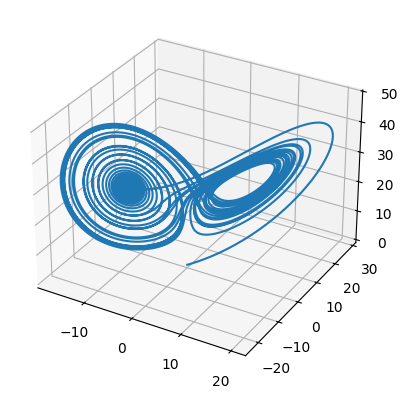

In [175]:
num_steps = 20000
dt = 0.002
ref_trajectory = []

env = LorenzAttractor()
initial_state = env.reset().copy()

for _ in range(num_steps):
    state = env.step(dt)
    ref_trajectory.append(state.copy())

ref_trajectory = numpy.array(ref_trajectory)
plot_3d_trajectory(ref_trajectory)


In [176]:
import AILibs

#optimizer = AILibs.sr3_fit
optimizer = AILibs.lr_fit
dictionary = AILibs.dictionary_cross_products


model = AILibs.system_identification_state(ref_trajectory, optimizer, dictionary)

model[model < 1e-8] = 0.0

print(model)

[[0.98       0.02       0.         0.         0.         0.        ]
 [0.056      0.998      0.         0.         0.         0.        ]
 [0.         0.         0.99466667 0.002      0.         0.        ]]
